In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "configs" / "training.yaml").exists():
            return candidate
    raise FileNotFoundError("Project root was not found")

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.artifacts import save_baseline_outputs
from src.models.data import load_modeling_dataset, resolve_feature_set
from src.models.training import CatBoostBaselineConfig, CrossValidationConfig, run_catboost_baseline, run_sanity_baseline

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")
np.random.seed(42)

In [2]:
model_config_raw = yaml.safe_load((PROJECT_ROOT / "configs" / "model.yaml").read_text(encoding="utf-8"))
training_config_raw = yaml.safe_load((PROJECT_ROOT / "configs" / "training.yaml").read_text(encoding="utf-8"))
processed_dir = PROJECT_ROOT / "data" / "processed"
dataset = load_modeling_dataset(processed_dir)

data_summary = pd.DataFrame({
    "artifact": ["X_train", "y_train", "X_test", "train_ids", "test_ids"],
    "rows": [len(dataset.X_train), len(dataset.y_train), len(dataset.X_test), len(dataset.train_ids), len(dataset.test_ids)],
    "columns": [dataset.X_train.shape[1], 1, dataset.X_test.shape[1], 1, 1],
})
display(data_summary)

,artifact,rows,columns
0,X_train,114321,313
1,y_train,114321,1
2,X_test,114393,313
3,train_ids,114321,1
4,test_ids,114393,1


In [3]:
catboost_raw = model_config_raw["catboost_baseline"]
cv_raw = training_config_raw["cross_validation"]
feature_specification = resolve_feature_set(dataset.manifest, catboost_raw["feature_set"])
cv_config = CrossValidationConfig(**cv_raw)
catboost_config = CatBoostBaselineConfig(
    parameters=catboost_raw["parameters"],
    early_stopping_rounds=catboost_raw["early_stopping_rounds"],
    verbose=catboost_raw["verbose"],
)

feature_summary = pd.Series({
    "feature_set": feature_specification.name,
    "total_features": len(feature_specification.feature_names),
    "numerical_features": len(feature_specification.feature_names) - len(feature_specification.categorical_names),
    "categorical_features": len(feature_specification.categorical_names),
    "feature_groups": ", ".join(feature_specification.feature_groups),
    "cv_splits": cv_config.n_splits,
    "random_state": cv_config.random_state,
})
display(feature_summary.to_frame("value"))

,value
feature_set,expert_base_only
total_features,25
numerical_features,12
categorical_features,13
feature_groups,"original_numerical, categorical_1way"
cv_splits,5
random_state,42


In [4]:
sanity_result = run_sanity_baseline(
    dataset,
    feature_specification,
    cv_config,
    strategy=training_config_raw["sanity_baseline"]["strategy"],
)
display(sanity_result.fold_metrics)
display(pd.DataFrame([sanity_result.overall_metrics], index=["dummy_prior_oof"]))

,model,feature_set,fold,train_rows,valid_rows,best_iteration,training_seconds,run_seconds,resumed,log_loss,roc_auc,average_precision,brier_score
0,dummy_prior,expert_base_only,1,91456,22865,<NA>,0.002978,0.003465,False,0.549685,0.500000,0.761207,0.181771
1,dummy_prior,expert_base_only,2,91457,22864,<NA>,0.002979,0.003981,False,0.549697,0.500000,0.761197,0.181776
2,dummy_prior,expert_base_only,3,91457,22864,<NA>,0.002115,0.002494,False,0.549697,0.500000,0.761197,0.181776
3,dummy_prior,expert_base_only,4,91457,22864,<NA>,0.001876,0.002256,False,0.549697,0.500000,0.761197,0.181776
4,dummy_prior,expert_base_only,5,91457,22864,<NA>,0.002322,0.002789,False,0.549697,0.500000,0.761197,0.181776


,log_loss,roc_auc,average_precision,brier_score
dummy_prior_oof,0.549694,0.499995,0.761197,0.181775


In [5]:
output_config = training_config_raw["outputs"]
model_dir = PROJECT_ROOT / output_config["model_dir"] if output_config["save_fold_models"] else None
catboost_result = run_catboost_baseline(
    dataset,
    feature_specification,
    cv_config,
    catboost_config,
    model_dir=model_dir,
    predict_test=output_config["save_test_predictions"],
    resume=output_config["resume_completed_folds"],
)
display(catboost_result.fold_metrics)
display(pd.DataFrame([catboost_result.overall_metrics], index=["catboost_oof"]))

,model,feature_set,fold,train_rows,valid_rows,best_iteration,training_seconds,run_seconds,resumed,log_loss,roc_auc,average_precision,brier_score
0,catboost,expert_base_only,1,91456,22865,998,132.362419,1.995681,True,0.445597,0.782659,0.916450,0.144531
1,catboost,expert_base_only,2,91457,22864,995,175.091406,2.041454,True,0.440975,0.789012,0.919835,0.142980
2,catboost,expert_base_only,3,91457,22864,981,175.478859,1.910928,True,0.443293,0.786190,0.918022,0.143757
3,catboost,expert_base_only,4,91457,22864,998,189.828027,1.960927,True,0.442969,0.785295,0.918838,0.143967
4,catboost,expert_base_only,5,91457,22864,976,203.460484,1.943119,True,0.442840,0.788340,0.918635,0.143692


,log_loss,roc_auc,average_precision,brier_score
catboost_oof,0.443135,0.786266,0.918336,0.143785


In [6]:
overall_comparison = pd.DataFrame([
    {"model": sanity_result.model_name, **sanity_result.overall_metrics},
    {"model": catboost_result.model_name, **catboost_result.overall_metrics},
]).sort_values("log_loss")
display(overall_comparison)

experiment_dir = PROJECT_ROOT / output_config["experiment_dir"]
saved_paths = save_baseline_outputs(
    sanity_result,
    catboost_result,
    dataset,
    cv_config,
    catboost_config,
    processed_dir,
    experiment_dir,
)
pd.Series({name: str(path.relative_to(PROJECT_ROOT)) for name, path in saved_paths.items()}, name="path").to_frame()

,model,log_loss,roc_auc,average_precision,brier_score
1,catboost,0.443135,0.786266,0.918336,0.143785
0,dummy_prior,0.549694,0.499995,0.761197,0.181775


,path
fold_metrics,reports\experiments\baseline\fold_metrics.csv
summary_metrics,reports\experiments\baseline\summary_metrics.csv
overall_metrics,reports\experiments\baseline\overall_metrics.csv
oof_predictions,reports\experiments\baseline\oof_predictions.p...
feature_importance,reports\experiments\baseline\catboost_feature_...
metadata,reports\experiments\baseline\training_metadata...
test_predictions,reports\experiments\baseline\test_predictions....


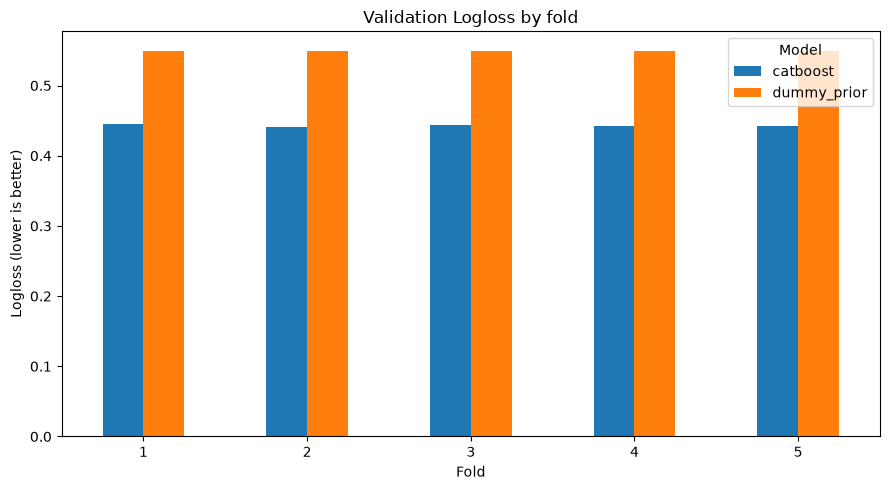

,index,feature,mean,std
22,22,v50,23.538312,0.755408
9,9,cat1__v66,12.860612,0.645656
8,8,cat1__v56,9.006099,0.712681
2,2,cat1__v22,6.865149,0.223234
24,24,v72,4.804334,0.346444
1,1,cat1__v113,4.238283,0.203779
11,11,cat1__v79,3.821433,0.509516
7,7,cat1__v52,3.630578,0.588584
6,6,cat1__v47,3.392161,0.656371
5,5,cat1__v31,3.254098,0.905104


In [7]:
figures_dir = PROJECT_ROOT / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
fold_plot = pd.concat([sanity_result.fold_metrics, catboost_result.fold_metrics], ignore_index=True)
pivot = fold_plot.pivot(index="fold", columns="model", values="log_loss")
ax = pivot.plot(kind="bar", figsize=(9, 5), rot=0)
ax.set_title("Validation Logloss by fold")
ax.set_xlabel("Fold")
ax.set_ylabel("Logloss (lower is better)")
ax.legend(title="Model")
plt.tight_layout()
plt.savefig(figures_dir / "baseline_cv_logloss.png", dpi=150, bbox_inches="tight")
plt.show()

importance_summary = catboost_result.feature_importance.groupby("feature", as_index=False)["importance"].agg(["mean", "std"]).reset_index().sort_values("mean", ascending=False)
display(importance_summary.head(15))

In [8]:
assert len(sanity_result.oof_predictions) == len(dataset.X_train)
assert len(catboost_result.oof_predictions) == len(dataset.X_train)
assert sanity_result.oof_predictions["fold"].equals(catboost_result.oof_predictions["fold"])
assert catboost_result.oof_predictions["catboost_probability"].between(0, 1).all()
assert catboost_result.oof_predictions["catboost_probability"].notna().all()
assert catboost_result.overall_metrics["log_loss"] < sanity_result.overall_metrics["log_loss"]
assert len(catboost_result.model_paths) == cv_config.n_splits
assert all(path.exists() for path in catboost_result.model_paths)
assert all(path.exists() for path in saved_paths.values())

validation_summary = pd.Series({
    "oof_rows": len(catboost_result.oof_predictions),
    "folds": cv_config.n_splits,
    "saved_fold_models": len(catboost_result.model_paths),
    "dummy_logloss": sanity_result.overall_metrics["log_loss"],
    "catboost_logloss": catboost_result.overall_metrics["log_loss"],
    "absolute_logloss_improvement": sanity_result.overall_metrics["log_loss"] - catboost_result.overall_metrics["log_loss"],
})
display(validation_summary.to_frame("value"))
print("BASELINE TRAINING COMPLETE")

,value
oof_rows,"114,321.000000"
folds,5.000000
saved_fold_models,5.000000
dummy_logloss,0.549694
catboost_logloss,0.443135
absolute_logloss_improvement,0.106560


BASELINE TRAINING COMPLETE
